# 03 — RSI Strategy

The Relative Strength Index (RSI) measures the ratio of recent gains to recent losses, normalized to [0, 100]:

$$RSI = 100 - \frac{100}{1 + RS}, \quad RS = \frac{\text{avg gain}}{{\text{avg loss}}}$$

Smoothing uses Wilder's exponential moving average (not a simple rolling mean).

**Signal rule:**
- RSI < 30 → oversold → long (1)
- RSI > 70 → overbought → short (-1)
- otherwise → flat (0)

RSI is a momentum indicator used as a mean-reversion signal: extreme readings suggest the move has gone too far and is likely to reverse. Like all mean-reversion approaches, it can fail badly in trending markets.

In [5]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import load_prices
from backtester import run
from metrics import summary, sharpe_ratio
from strategies.rsi import signals, compute_rsi

In [6]:
ticker = 'SW'
start  = '2022-01-01'
end    = '2024-01-01'

prices = load_prices(ticker, start, end)

window     = 7
oversold   = 30
overbought = 70

sig, rsi = signals(prices, window=window, oversold=oversold, overbought=overbought)
result   = run(prices, sig, initial_capital=10_000, transaction_cost=0.001)

print(f"Performance ({ticker}, {start} — {end})")
print(f"  RSI({window}), oversold={oversold}, overbought={overbought}")
print()
summary(result['equity'], result['strategy_ret'])

Performance (SW, 2022-01-01 — 2024-01-01)
  RSI(7), oversold=30, overbought=70

  Annualized return     : 32.28%
  Sharpe ratio          : 1.03
  Max drawdown          : -27.96%
  Calmar ratio          : 1.15
  Win rate              : 35.85%
  Total trades          : 159


{'Annualized return': '32.28%',
 'Sharpe ratio': '1.03',
 'Max drawdown': '-27.96%',
 'Calmar ratio': '1.15',
 'Win rate': '35.85%',
 'Total trades': 159}

## RSI over time with threshold lines

The RSI panel is the standard way to visualize this strategy. Shaded regions highlight when the indicator is in signal territory.

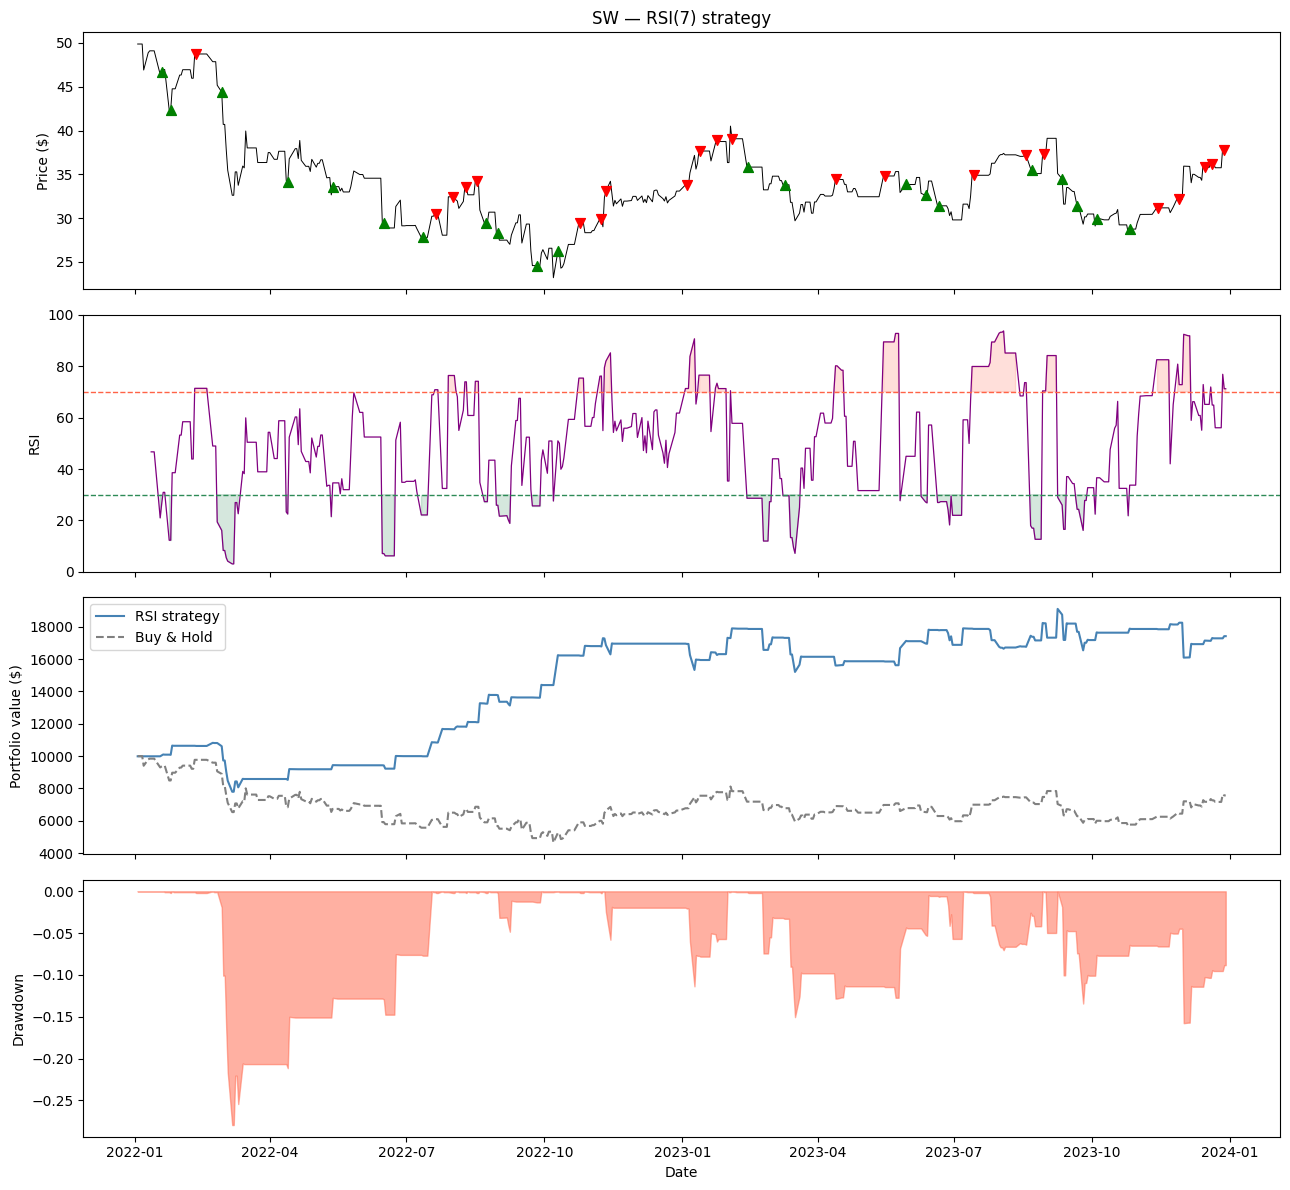

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

# price with trade markers
buys   = result[(result['trade'] == 1) & (result['position'] ==  1)]
shorts = result[(result['trade'] == 1) & (result['position'] == -1)]

axes[0].plot(prices.index, prices, color='black', linewidth=0.7)
axes[0].scatter(buys.index,   buys['price'],   marker='^', color='green', s=50, zorder=5)
axes[0].scatter(shorts.index, shorts['price'], marker='v', color='red',   s=50, zorder=5)
axes[0].set_ylabel('Price ($)')
axes[0].set_title(f'{ticker} — RSI({window}) strategy')

# RSI panel
axes[1].plot(rsi.index, rsi, color='purple', linewidth=0.9)
axes[1].axhline(overbought, color='tomato',   linestyle='--', linewidth=1)
axes[1].axhline(oversold,   color='seagreen', linestyle='--', linewidth=1)
axes[1].fill_between(rsi.index, rsi, overbought, where=(rsi > overbought), alpha=0.2, color='tomato')
axes[1].fill_between(rsi.index, rsi, oversold,   where=(rsi < oversold),   alpha=0.2, color='seagreen')
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('RSI')

# equity curves
axes[2].plot(result.index, result['equity'],    label='RSI strategy', color='steelblue')
axes[2].plot(result.index, result['bh_equity'], label='Buy & Hold',   color='gray', linestyle='--')
axes[2].set_ylabel('Portfolio value ($)')
axes[2].legend()

# drawdown
rolling_max = result['equity'].cummax()
drawdown    = (result['equity'] - rolling_max) / rolling_max
axes[3].fill_between(result.index, drawdown, 0, color='tomato', alpha=0.5)
axes[3].set_ylabel('Drawdown')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.show()

## Threshold sensitivity

Tighter thresholds (e.g. 20/80) fire fewer signals but each is a more extreme reading. Looser thresholds (40/60) trade more frequently but on weaker signals.

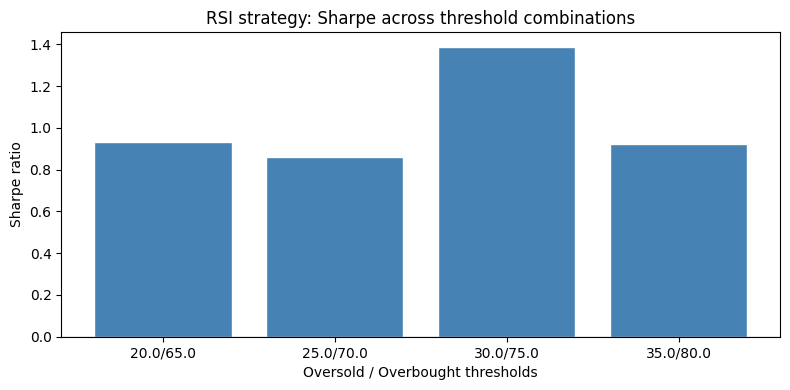

In [8]:
oversold_levels   = [20, 25, 30, 35]
overbought_levels = [65, 70, 75, 80]

results_list = []
for os, ob in zip(oversold_levels, overbought_levels):
    sig, _ = signals(prices, window=14, oversold=os, overbought=ob)
    res    = run(prices, sig)
    sr     = sharpe_ratio(res['strategy_ret'])
    results_list.append({'oversold': os, 'overbought': ob, 'sharpe': sr})

sweep_df = pd.DataFrame(results_list)
labels   = [f"{r['oversold']}/{r['overbought']}" for _, r in sweep_df.iterrows()]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, sweep_df['sharpe'], color='steelblue', edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Oversold / Overbought thresholds')
ax.set_ylabel('Sharpe ratio')
ax.set_title('RSI strategy: Sharpe across threshold combinations')
plt.tight_layout()
plt.show()